In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from Preprocess import preprocess_data_window
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
#filtered_time = pd.read_csv("filtered_time_normalized.csv", index_col=0)
#data_orig = data_orig.loc[filtered_time.index]


# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

DROP_TIME_SINCE = False  # ← toggle here: True to drop, False to keep

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events)

print(f"drop_time_since: {DROP_TIME_SINCE}")
print(f"Features used: {[c.split('-')[0] for c in feature_cols]}")
#print("NaN count per column:\n", X_train.isna().sum())
#print("Total NaN:", X_train.isna().sum().sum())

X shape:  (2822, 126)
y shape:  (2822,)
drop_time_since: False
Features used: ['tide_deriv', 'form_fac', 'time_since', 'slip_size', 'high_t_evt', 'tide_height']


In [4]:

SHORT_THRESHOLD = 65_000  # seconds — boundary between short and long classes

# ------------------------------------------------------------------
# 1. Build binary labels from the existing y splits


y_clf_train = (y_train >= SHORT_THRESHOLD).astype(int)
y_clf_val   = (y_val   >= SHORT_THRESHOLD).astype(int)
y_clf_test  = (y_test  >= SHORT_THRESHOLD).astype(int)

# X_train / X_val / X_test are used directly as classifier features —
# the 20-event lag window already encodes the rolling history needed.


print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")
print(f"Class distribution (val)   — Short: {(y_clf_val==0).sum()},   Long: {(y_clf_val==1).sum()}")
print(f"Class distribution (test)  — Short: {(y_clf_test==0).sum()},  Long: {(y_clf_test==1).sum()}")

# Sample weights to handle class imbalance
sample_weights_train = compute_sample_weight("balanced", y_clf_train)

# ------------------------------------------------------------------
# 2. Optuna tuning for the classifier
# ------------------------------------------------------------------

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
        eval_metric="logloss",
    )
    clf.fit(
        X_train, y_clf_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_val, y_clf_val)],
        verbose=False,
    )
    preds = clf.predict(X_val)
    return 1.0 - accuracy_score(y_clf_val, preds)  # minimise misclassification rate

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

clf_best_params = clf_study.best_params
print("\nClassifier optimal parameters:", clf_best_params)

# ------------------------------------------------------------------
# 3. Train final classifier with optimal parameters
# ------------------------------------------------------------------

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train, y_clf_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_clf_val)],
    verbose=False,
)

# ------------------------------------------------------------------
# 4. Evaluate classifier on held-out test set
# ------------------------------------------------------------------

clf_test_preds = slip_classifier.predict(X_test)

print("\n=== Classifier Test Performance ===")
print(classification_report(y_clf_test, clf_test_preds,target_names=["Short (<65k s)", "Long (>=65k s)"]))
print(f"Test Accuracy: {accuracy_score(y_clf_test, clf_test_preds):.4f}")

[I 2026-04-13 12:26:52,091] A new study created in memory with name: no-name-903879de-67c9-47e0-ae97-ce25f4a5e1d0


Class distribution (train) — Short: 1054, Long: 638
Class distribution (val)   — Short: 358,   Long: 207
Class distribution (test)  — Short: 367,  Long: 198


[I 2026-04-13 12:26:56,033] Trial 0 finished with value: 0.21592920353982303 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 6, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111, 'scale_pos_weight': 0.8900466011060912}. Best is trial 0 with value: 0.21592920353982303.
[I 2026-04-13 12:26:56,902] Trial 1 finished with value: 0.3292035398230089 and parameters: {'learning_rate': 0.015957084694148364, 'max_depth': 2, 'subsample': 0.8598528437324806, 'colsample_bytree': 0.7803345035229626, 'scale_pos_weight': 2.2701814444901136}. Best is trial 0 with value: 0.21592920353982303.
[I 2026-04-13 12:26:59,222] Trial 2 finished with value: 0.23539823008849559 and parameters: {'learning_rate': 0.010636066512540286, 'max_depth': 6, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'scale_pos_weight': 0.9545624180177515}. Best is trial 0 with value: 0.21592920353982303.
[I 2026-04-13 12:27:00,135] Trial 3 finished with value: 0.2477876


Classifier optimal parameters: {'learning_rate': 0.030725089676543242, 'max_depth': 5, 'subsample': 0.802729564201302, 'colsample_bytree': 0.6101223502561892, 'scale_pos_weight': 0.5410898790549821}

=== Classifier Test Performance ===
                precision    recall  f1-score   support

Short (<65k s)       0.88      0.88      0.88       367
Long (>=65k s)       0.77      0.77      0.77       198

      accuracy                           0.84       565
     macro avg       0.82      0.82      0.82       565
  weighted avg       0.84      0.84      0.84       565

Test Accuracy: 0.8389


In [5]:


import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

SHORT_LOWER, SHORT_UPPER = 25_000,  65_000
LONG_LOWER,  LONG_UPPER  = 65_000, 100_000

# ------------------------------------------------------------------
# 1. Convert to numpy and split by TRUE label for sub-model training
# ------------------------------------------------------------------

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

X_train_np = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.array(X_train)
X_val_np   = X_val.to_numpy()   if hasattr(X_val,   "to_numpy") else np.array(X_val)
X_test_np  = X_test.to_numpy()  if hasattr(X_test,  "to_numpy") else np.array(X_test)

short_mask_train = y_train_np < SHORT_THRESHOLD
long_mask_train  = ~short_mask_train
short_mask_val   = y_val_np   < SHORT_THRESHOLD
long_mask_val    = ~short_mask_val

X_tr_short, y_tr_short = X_train_np[short_mask_train], y_train_np[short_mask_train]
X_vl_short, y_vl_short = X_val_np[short_mask_val],     y_val_np[short_mask_val]
X_tr_long,  y_tr_long  = X_train_np[long_mask_train],  y_train_np[long_mask_train]
X_vl_long,  y_vl_long  = X_val_np[long_mask_val],      y_val_np[long_mask_val]

print(f"Sub-regressor training samples — Short: {len(y_tr_short)}, Long: {len(y_tr_long)}")

# ------------------------------------------------------------------
# 2. Optuna tuning — SHORT sub-regressor


def objective_short(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_short, y_tr_short,
              eval_set=[(X_vl_short, y_vl_short)], verbose=False)
    preds = np.clip(model.predict(X_vl_short), SHORT_LOWER, SHORT_UPPER)
    return root_mean_squared_error(y_vl_short, preds)

opt_short = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
opt_short.optimize(objective_short, n_trials=30)
print("Short sub-regressor optimal params:", opt_short.best_params)

# ------------------------------------------------------------------
# 3. Optuna tuning — LONG sub-regressor
# ------------------------------------------------------------------

def objective_long(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_long, y_tr_long,
              eval_set=[(X_vl_long, y_vl_long)], verbose=False)
    preds = np.clip(model.predict(X_vl_long), LONG_LOWER, LONG_UPPER)
    return root_mean_squared_error(y_vl_long, preds)

opt_long = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42))
opt_long.optimize(objective_long, n_trials=30)
print("Long sub-regressor optimal params:", opt_long.best_params)

# ------------------------------------------------------------------
# 4. Train final sub-regressors
# ------------------------------------------------------------------

XGBoost_short = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_short.best_params,
    random_state=42,
)
XGBoost_short.fit(X_tr_short, y_tr_short,
                  eval_set=[(X_vl_short, y_vl_short)], verbose=False)

XGBoost_long = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_long.best_params,
    random_state=42,
)
XGBoost_long.fit(X_tr_long, y_tr_long,
                 eval_set=[(X_vl_long, y_vl_long)], verbose=False)

# ------------------------------------------------------------------
# 5. Inference — classifier routes

clf_test_labels = slip_classifier.predict(X_test_np)

final_predictions = np.empty(len(X_test_np))
short_idx = np.where(clf_test_labels == 0)[0]
long_idx  = np.where(clf_test_labels == 1)[0]

if len(short_idx) > 0:
    final_predictions[short_idx] = XGBoost_short.predict(X_test_np[short_idx])

if len(long_idx) > 0:
    final_predictions[long_idx] = XGBoost_long.predict(X_test_np[long_idx])



# Soft range warnings (monitor without distorting metrics)
n_below_short = np.sum(final_predictions[short_idx] < SHORT_LOWER) if len(short_idx) > 0 else 0
n_above_short = np.sum(final_predictions[short_idx] > SHORT_UPPER) if len(short_idx) > 0 else 0
n_below_long  = np.sum(final_predictions[long_idx]  < LONG_LOWER)  if len(long_idx)  > 0 else 0
n_above_long  = np.sum(final_predictions[long_idx]  > LONG_UPPER)  if len(long_idx)  > 0 else 0

if n_below_short + n_above_short + n_below_long + n_above_long > 0:
    print(f"\n[Soft range warnings — predictions outside guidance ranges]")
    print(f"  Short sub-regressor: {n_below_short} below {SHORT_LOWER:,}s, "
          f"{n_above_short} above {SHORT_UPPER:,}s")
    print(f"  Long  sub-regressor: {n_below_long}  below {LONG_LOWER:,}s,  "
          f"{n_above_long}  above {LONG_UPPER:,}s")

# ------------------------------------------------------------------
# 6. Evaluate
# ------------------------------------------------------------------

overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Constrained XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")

# Per-class breakdown by true label (not classifier label)
short_true_idx = np.where(y_test_np < SHORT_THRESHOLD)[0]
long_true_idx  = np.where(y_test_np >= SHORT_THRESHOLD)[0]

if len(short_true_idx) > 0:
    rmse_s = root_mean_squared_error(y_test_np[short_true_idx], final_predictions[short_true_idx])
    mae_s  = mean_absolute_error(y_test_np[short_true_idx],     final_predictions[short_true_idx])
    print(f"\nShort class (true <{SHORT_THRESHOLD:,}s, n={len(short_true_idx)}) — "
          f"RMSE: {rmse_s:.2f}s  MAE: {mae_s:.2f}s")

if len(long_true_idx) > 0:
    rmse_l = root_mean_squared_error(y_test_np[long_true_idx], final_predictions[long_true_idx])
    mae_l  = mean_absolute_error(y_test_np[long_true_idx],     final_predictions[long_true_idx])
    print(f"Long  class (true >={SHORT_THRESHOLD:,}s, n={len(long_true_idx)}) — "
          f"RMSE: {rmse_l:.2f}s  MAE: {mae_l:.2f}s")

true_clf_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)
routing_acc     = accuracy_score(true_clf_labels, clf_test_labels)
n_misrouted     = np.sum(clf_test_labels != true_clf_labels)
print(f"\nClassifier routing accuracy: {routing_acc:.4f}  "
      f"({n_misrouted} misrouted / {len(y_test_np)} total)")

[I 2026-04-13 12:27:51,178] A new study created in memory with name: no-name-38684f41-c4a1-477f-844d-b21f5cf6585b


Sub-regressor training samples — Short: 1054, Long: 638


[I 2026-04-13 12:27:54,049] Trial 0 finished with value: 5232.057711107786 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 5232.057711107786.
[I 2026-04-13 12:27:54,830] Trial 1 finished with value: 5910.541845284317 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 5232.057711107786.
[I 2026-04-13 12:27:56,737] Trial 2 finished with value: 5496.890782057335 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 5232.057711107786.
[I 2026-04-13 12:27:57,617] Trial 3 finished with value: 5838.302517769992 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 2, 'subsample': 0.6545474901621302, 'colsample_bytree'

Short sub-regressor optimal params: {'learning_rate': 0.03452004928010984, 'max_depth': 5, 'subsample': 0.8726476327816355, 'colsample_bytree': 0.7299498082383352}


[I 2026-04-13 12:28:46,702] Trial 0 finished with value: 6451.415776135843 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 6451.415776135843.
[I 2026-04-13 12:28:47,296] Trial 1 finished with value: 6537.50741344358 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 6451.415776135843.
[I 2026-04-13 12:28:48,609] Trial 2 finished with value: 6672.7092991002455 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 6451.415776135843.
[I 2026-04-13 12:28:49,196] Trial 3 finished with value: 6635.811129672979 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 2, 'subsample': 0.6545474901621302, 'colsample_bytree'

Long sub-regressor optimal params: {'learning_rate': 0.011980062356484713, 'max_depth': 4, 'subsample': 0.7094680627982055, 'colsample_bytree': 0.8327155113866201}

=== Constrained XGBoost — Overall Test Performance ===
RMSE: 16888.34 s
MAE:  8932.49 s

Short class (true <65,000s, n=367) — RMSE: 15324.44s  MAE: 7769.18s
Long  class (true >=65,000s, n=198) — RMSE: 19457.45s  MAE: 11088.74s

Classifier routing accuracy: 0.8389  (91 misrouted / 565 total)


Sample    0: True=87450s  Pred=85669s  Error=1781s  Routed→Long
Sample    1: True=58215s  Pred=54499s  Error=3716s  Routed→Short
Sample    2: True=88560s  Pred=88657s  Error=97s  Routed→Long
Sample    3: True=31005s  Pred=38743s  Error=7738s  Routed→Short
Sample    4: True=36825s  Pred=40824s  Error=3999s  Routed→Short
Sample    5: True=95370s  Pred=86593s  Error=8777s  Routed→Long
Sample    6: True=61440s  Pred=82087s  Error=20647s  Routed→Long  ← MISROUTED
Sample    7: True=52110s  Pred=47868s  Error=4242s  Routed→Short
Sample    8: True=56520s  Pred=47501s  Error=9019s  Routed→Short
Sample    9: True=35355s  Pred=43806s  Error=8451s  Routed→Short
Sample   10: True=87870s  Pred=87415s  Error=455s  Routed→Long
Sample   11: True=31620s  Pred=87681s  Error=56061s  Routed→Long  ← MISROUTED
Sample   12: True=39930s  Pred=33505s  Error=6425s  Routed→Short
Sample   13: True=28455s  Pred=86739s  Error=58284s  Routed→Long  ← MISROUTED
Sample   14: True=33600s  Pred=87157s  Error=53557s  Route

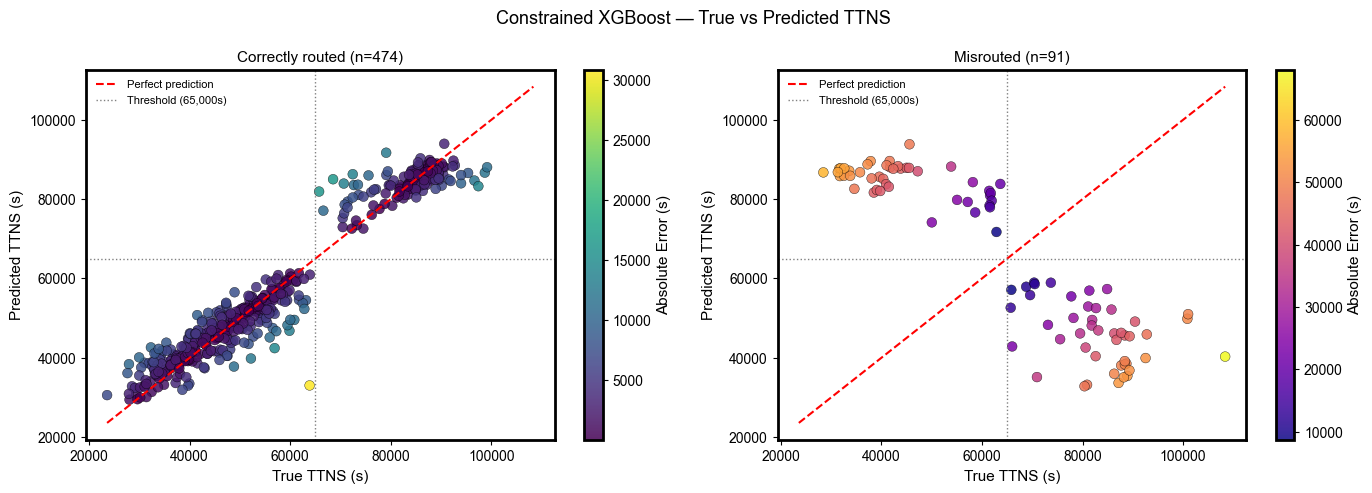

In [9]:
# ============================================================
# XGBoost Constrained Pipeline — Sample-level Analysis
# ============================================================

y_test_secs      = y_test_np                  # true values (seconds)
XG_pred_secs     = final_predictions          # constrained pipeline predictions
clf_labels_test  = clf_test_labels            # 0=short, 1=long (classifier routing)
true_clf_labels  = (y_test_np >= SHORT_THRESHOLD).astype(int)
misrouted_mask   = clf_labels_test != true_clf_labels

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

# Per-sample printout with routing info
for i, (true, pred, abs_err, routed, correct_route) in enumerate(zip(
        y_test_secs, XG_pred_secs, absolute_error_secs_XG,
        clf_labels_test, true_clf_labels)):
    route_str   = "Long" if routed == 1 else "Short"
    correct_str = "" if routed == correct_route else "  ← MISROUTED"
    print(f"Sample {i:4d}: True={true:.0f}s  Pred={pred:.0f}s  "
          f"Error={abs_err:.0f}s  Routed→{route_str}{correct_str}")

# Scatter plot coloured by routing correctness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Constrained XGBoost — True vs Predicted TTNS", fontsize=13)

correctly_routed = ~misrouted_mask

for ax, mask, label, colour in [
        (axes[0], correctly_routed, "Correctly routed", "viridis"),
        (axes[1], misrouted_mask,   "Misrouted",        "plasma")]:
    if mask.sum() == 0:
        ax.set_title(f"{label} (none)")
        continue
    sc = ax.scatter(y_test_secs[mask], XG_pred_secs[mask],
                    c=absolute_error_secs_XG[mask], cmap=colour,
                    s=50, edgecolors="black", linewidths=0.3, alpha=0.85)
    plt.colorbar(sc, ax=ax, label="Absolute Error (s)")
    ax.plot([y_test_secs.min(), y_test_secs.max()],
            [y_test_secs.min(), y_test_secs.max()],
            'r--', linewidth=1.5, label='Perfect prediction')
    # Draw threshold line
    ax.axvline(SHORT_THRESHOLD, color='grey', linestyle=':', linewidth=1,
               label=f'Threshold ({SHORT_THRESHOLD:,}s)')
    ax.axhline(SHORT_THRESHOLD, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel("True TTNS (s)")
    ax.set_ylabel("Predicted TTNS (s)")
    ax.set_title(f"{label} (n={mask.sum()})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

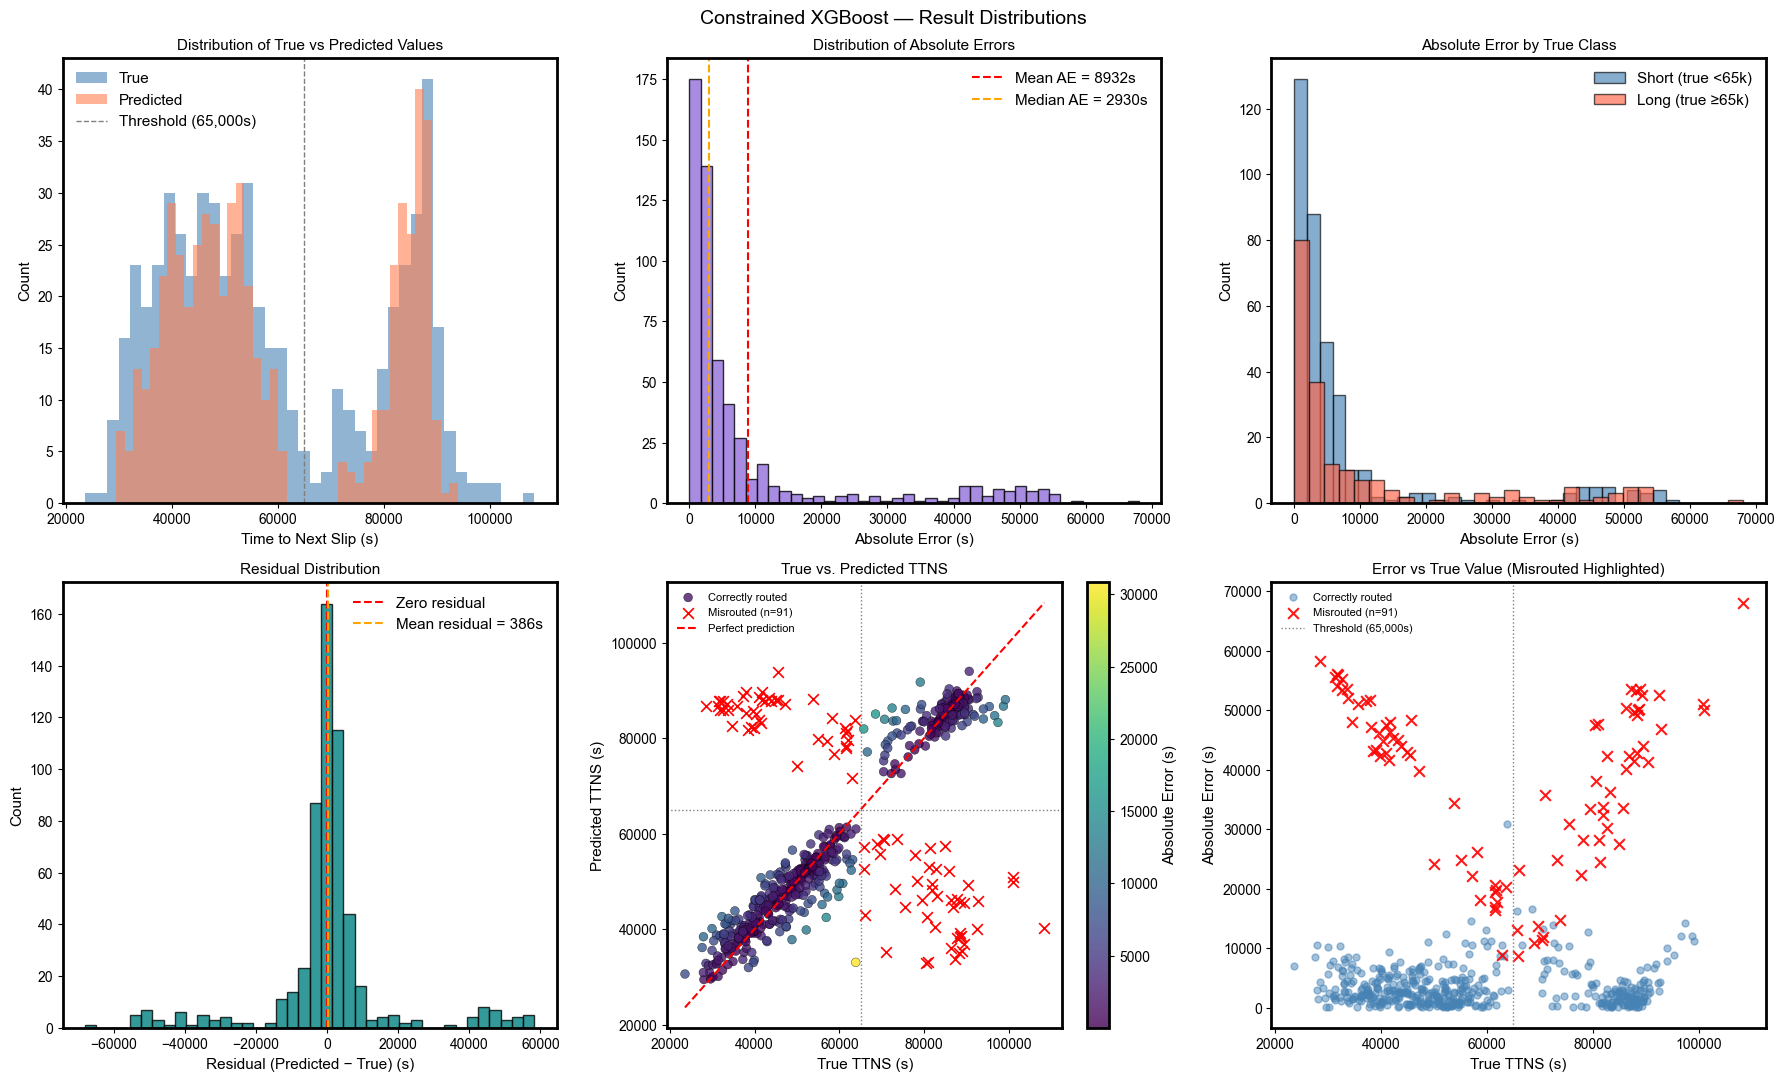

=== Overall ===
MAE:              8932.49s
Median AE:        2929.55s
RMSE:             16888.34s
R²:               0.2969
Max error:        68060.92s
% within 5,000s:  65.8%
% within 9,000s:  78.9%
Misrouted events: 91 / 565

=== Short class (true <65,000s, n=367) ===
MAE:    7769.18s
Median AE: 2884.60s
RMSE:   15324.44s
R²:     -1.7720

=== Long class (true ≥65,000s, n=198) ===
MAE:    11088.74s
Median AE: 3018.78s
RMSE:   19457.45s
R²:     -6.1229


In [10]:
# ============================================================
# XGBoost Constrained Pipeline — Distribution & Error Analysis
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

y_test_secs    = y_test_np
XG_pred_secs   = final_predictions
misrouted_mask = clf_test_labels != (y_test_np >= SHORT_THRESHOLD).astype(int)

absolute_errors = np.abs(XG_pred_secs - y_test_secs)
residuals       = XG_pred_secs - y_test_secs

# Sub-group indices (by TRUE label, for honest per-class reporting)
short_true_idx = np.where(y_test_np < SHORT_THRESHOLD)[0]
long_true_idx  = np.where(y_test_np >= SHORT_THRESHOLD)[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Constrained XGBoost — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted ───────────────────────────────
axes[0, 0].hist(y_test_secs,  bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(XG_pred_secs, bins=40, alpha=0.6, color='coral',     label='Predicted')
axes[0, 0].axvline(SHORT_THRESHOLD, color='grey', linestyle='--', linewidth=1,
                    label=f'Threshold ({SHORT_THRESHOLD:,}s)')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ─────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple',
                edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(),    color='red',    linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Per-class absolute error distributions ──────────────────────────
axes[0, 2].hist(absolute_errors[short_true_idx], bins=30, alpha=0.65,
                color='steelblue', edgecolor='black', label='Short (true <65k)')
axes[0, 2].hist(absolute_errors[long_true_idx],  bins=30, alpha=0.65,
                color='tomato',    edgecolor='black', label='Long (true ≥65k)')
axes[0, 2].set_xlabel("Absolute Error (s)")
axes[0, 2].set_ylabel("Count")
axes[0, 2].set_title("Absolute Error by True Class")
axes[0, 2].legend()

# ── Panel 4: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted − True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 5: True vs Predicted scatter (coloured by class routing) ────────────
correct_mask   = ~misrouted_mask
sc1 = axes[1, 1].scatter(y_test_secs[correct_mask], XG_pred_secs[correct_mask],
                          c=absolute_errors[correct_mask], cmap='viridis',
                          s=40, edgecolors='black', linewidths=0.3,
                          alpha=0.8, label='Correctly routed')
if misrouted_mask.sum() > 0:
    axes[1, 1].scatter(y_test_secs[misrouted_mask], XG_pred_secs[misrouted_mask],
                       c='red', marker='x', s=60, linewidths=1.2,
                       label=f'Misrouted (n={misrouted_mask.sum()})')
plt.colorbar(sc1, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].axvline(SHORT_THRESHOLD, color='grey', linestyle=':', linewidth=1)
axes[1, 1].axhline(SHORT_THRESHOLD, color='grey', linestyle=':', linewidth=1)
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend(fontsize=8)

# ── Panel 6: Error vs True value (highlights misrouted events) ───────────────
axes[1, 2].scatter(y_test_secs[correct_mask], absolute_errors[correct_mask],
                   alpha=0.5, s=25, color='steelblue', label='Correctly routed')
if misrouted_mask.sum() > 0:
    axes[1, 2].scatter(y_test_secs[misrouted_mask], absolute_errors[misrouted_mask],
                       alpha=0.9, s=60, color='red', marker='x',
                       label=f'Misrouted (n={misrouted_mask.sum()})')
axes[1, 2].axvline(SHORT_THRESHOLD, color='grey', linestyle=':', linewidth=1,
                    label=f'Threshold ({SHORT_THRESHOLD:,}s)')
axes[1, 2].set_xlabel("True TTNS (s)")
axes[1, 2].set_ylabel("Absolute Error (s)")
axes[1, 2].set_title("Error vs True Value (Misrouted Highlighted)")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print("=== Overall ===")
print(f"MAE:              {mean_absolute_error(y_test_secs, XG_pred_secs):.2f}s")
print(f"Median AE:        {np.median(absolute_errors):.2f}s")
print(f"RMSE:             {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R²:               {r2_score(y_test_secs, XG_pred_secs):.4f}")
print(f"Max error:        {absolute_errors.max():.2f}s")
print(f"% within 5,000s:  {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9,000s:  {(absolute_errors < 9000).mean()*100:.1f}%")
print(f"Misrouted events: {misrouted_mask.sum()} / {len(y_test_np)}")

if len(short_true_idx) > 0:
    print(f"\n=== Short class (true <{SHORT_THRESHOLD:,}s, n={len(short_true_idx)}) ===")
    print(f"MAE:    {mean_absolute_error(y_test_secs[short_true_idx], XG_pred_secs[short_true_idx]):.2f}s")
    print(f"Median AE: {np.median(absolute_errors[short_true_idx]):.2f}s")
    print(f"RMSE:   {np.sqrt(np.mean(residuals[short_true_idx]**2)):.2f}s")
    print(f"R²:     {r2_score(y_test_secs[short_true_idx], XG_pred_secs[short_true_idx]):.4f}")

if len(long_true_idx) > 0:
    print(f"\n=== Long class (true ≥{SHORT_THRESHOLD:,}s, n={len(long_true_idx)}) ===")
    print(f"MAE:    {mean_absolute_error(y_test_secs[long_true_idx], XG_pred_secs[long_true_idx]):.2f}s")
    print(f"Median AE: {np.median(absolute_errors[long_true_idx]):.2f}s")
    print(f"RMSE:   {np.sqrt(np.mean(residuals[long_true_idx]**2)):.2f}s")
    print(f"R²:     {r2_score(y_test_secs[long_true_idx], XG_pred_secs[long_true_idx]):.4f}")

# Trying to get the correct figures! 

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 2,        # box thickness
    "axes.edgecolor": "black",
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False
})
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

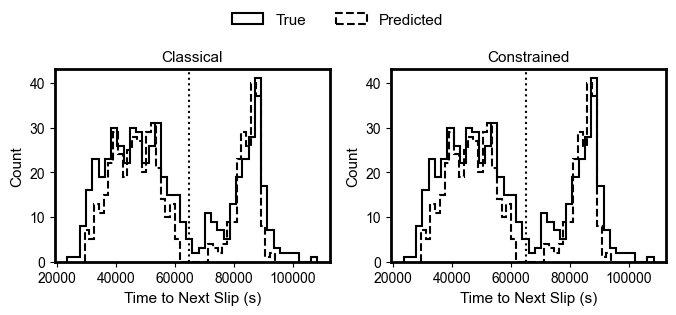

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ── Global style already assumed set ──

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

# ============================================================
# FIGURE 2 — BIMODAL DISTRIBUTION (DOUBLE PANEL)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(6.89, 3.2))  # double column

# ── PANEL A: Classical XGBoost ─────────────────────────────
y_classical = y_test if isinstance(y_test, np.ndarray) else y_test.to_numpy()
pred_classical = XG_pred_secs

axes[0].hist(
    y_classical,
    bins=40,
    histtype='step',
    linestyle='-',
    color='black',
    linewidth=1.5,
    label='True'
)

axes[0].hist(
    pred_classical,
    bins=40,
    histtype='step',
    linestyle='--',
    color='black',
    linewidth=1.5,
    label='Predicted'
)

axes[0].axvline(
    SHORT_THRESHOLD,
    linestyle=':',
    color='black',
    linewidth=1.5
)

axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Classical")

style_axes(axes[0])

# ── PANEL B: Constrained XGBoost ───────────────────────────
axes[1].hist(
    y_test_np,
    bins=40,
    histtype='step',
    linestyle='-',
    color='black',
    linewidth=1.5,
    label='True'
)

axes[1].hist(
    final_predictions,
    bins=40,
    histtype='step',
    linestyle='--',
    color='black',
    linewidth=1.5,
    label='Predicted'
)

axes[1].axvline(
    SHORT_THRESHOLD,
    linestyle=':',
    color='black',
    linewidth=1.5
)

axes[1].set_xlabel("Time to Next Slip (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Constrained")

style_axes(axes[1])

# ── Shared legend (line style = encoding) ──────────────────
fig.legend(
    handles=axes[0].get_legend_handles_labels()[0],
    labels=axes[0].get_legend_handles_labels()[1],
    loc='upper center',
    ncol=2
)

# ── Layout + save ─────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

plt.savefig(
    "figure_bimodal_doublepanel.png",
    dpi=600,
    bbox_inches='tight'
)

plt.close()

In [ ]:
# Figures: 
fig, axes = plt.subplots(1, 2, figsize=(6.89, 3.2))  # double column, short height

# ── PANEL A: Classical ─────────────────────────────
axes[0].hist(y_test, bins=40,
             histtype='step', linestyle='-',
             color='black', linewidth=1.5,
             label='True')

axes[0].hist(XGBoost_Prediction, bins=40,
             histtype='step', linestyle='--',
             color='black', linewidth=1.5,
             label='Predicted')

axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Classical")

style_axes(axes[0])

# ── PANEL B: Constrained ───────────────────────────
axes[1].hist(y_test_np, bins=40,
             histtype='step', linestyle='-',
             color='black', linewidth=1.5,
             label='True')

axes[1].hist(final_predictions, bins=40,
             histtype='step', linestyle='--',
             color='black', linewidth=1.5,
             label='Predicted')

axes[1].axvline(SHORT_THRESHOLD,
                linestyle=':',
                color='black',
                linewidth=1.5)

axes[1].set_xlabel("Time to Next Slip (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Constrained")

style_axes(axes[1])

# Shared legend (double encoding: line style)
fig.legend(loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("figure_bimodal_doublepanel.png", dpi=600, bbox_inches='tight')
plt.close()

In [7]:
# How much is misrouting hurting per regime
clf_test_labels  = slip_classifier.predict(X_test_np)
true_test_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)

# Correctly routed short samples
correct_short = np.where(
    (true_test_labels == 0) & (clf_test_labels == 0)
)[0]
# Misrouted short samples (truly short but sent to long regressor)
misrouted_short = np.where(
    (true_test_labels == 0) & (clf_test_labels == 1)
)[0]

# Correctly routed long samples
correct_long = np.where(
    (true_test_labels == 1) & (clf_test_labels == 1)
)[0]
# Misrouted long samples (truly long but sent to short regressor)
misrouted_long = np.where(
    (true_test_labels == 1) & (clf_test_labels == 0)
)[0]

print(f"Correctly routed short (n={len(correct_short)}): "
      f"MAE = {mean_absolute_error(y_test_np[correct_short], final_predictions[correct_short]):.2f}s")
print(f"Misrouted short (n={len(misrouted_short)}): "
      f"MAE = {mean_absolute_error(y_test_np[misrouted_short], final_predictions[misrouted_short]):.2f}s"
      if len(misrouted_short) > 0 else "Misrouted short: none")

print(f"Correctly routed long (n={len(correct_long)}): "
      f"MAE = {mean_absolute_error(y_test_np[correct_long], final_predictions[correct_long]):.2f}s")
print(f"Misrouted long (n={len(misrouted_long)}): "
      f"MAE = {mean_absolute_error(y_test_np[misrouted_long], final_predictions[misrouted_long]):.2f}s"
      if len(misrouted_long) > 0 else "Misrouted long: none")

Correctly routed short (n=322): MAE = 3309.44s
Misrouted short (n=45): MAE = 39681.03s
Correctly routed long (n=152): MAE = 3345.66s
Misrouted long (n=46): MAE = 36674.58s


In [8]:
# ── CELL A: Classical MAEs comparable to quantum regime printout ──────────────
#
# Quantum prints:
#   Short regime val MAE: X  — all true-short val samples, short regressor
#   Long  regime val MAE: X  — all true-long  val samples, long  regressor
# Both assume perfect routing. This cell prints the same number for classical
# then also breaks down correctly-routed vs misrouted for completeness.

from sklearn.metrics import mean_absolute_error
import numpy as np

# ── Perfect-routing MAE (directly comparable to quantum printout) ─────────────
classical_short_mae = mean_absolute_error(
    y_vl_short, XGBoost_short.predict(X_vl_short)
)
classical_long_mae = mean_absolute_error(
    y_vl_long, XGBoost_long.predict(X_vl_long)
)

# ── Classifier-routed val breakdown ───────────────────────────────────────────
clf_val_labels   = slip_classifier.predict(X_val_np)
true_val_labels  = (y_val_np >= SHORT_THRESHOLD).astype(int)

short_val_routed = np.where(clf_val_labels == 0)[0]
long_val_routed  = np.where(clf_val_labels == 1)[0]

correct_short_val = short_val_routed[true_val_labels[short_val_routed] == 0]
misrouted_to_short= short_val_routed[true_val_labels[short_val_routed] == 1]  # true long sent to short
correct_long_val  = long_val_routed[true_val_labels[long_val_routed] == 1]
misrouted_to_long = long_val_routed[true_val_labels[long_val_routed] == 0]    # true short sent to long

mae_correct_short   = mean_absolute_error(y_val_np[correct_short_val],
    XGBoost_short.predict(X_val_np[correct_short_val])) if len(correct_short_val) > 0 else float('nan')
mae_misrouted_short = mean_absolute_error(y_val_np[misrouted_to_short],
    XGBoost_short.predict(X_val_np[misrouted_to_short])) if len(misrouted_to_short) > 0 else float('nan')
mae_correct_long    = mean_absolute_error(y_val_np[correct_long_val],
    XGBoost_long.predict(X_val_np[correct_long_val]))  if len(correct_long_val) > 0 else float('nan')
mae_misrouted_long  = mean_absolute_error(y_val_np[misrouted_to_long],
    XGBoost_long.predict(X_val_np[misrouted_to_long])) if len(misrouted_to_long) > 0 else float('nan')

print("=" * 68)
print("CLASSICAL vs QUANTUM — Val MAE Comparison")
print("=" * 68)
print(f"\n── Assuming perfect routing (directly comparable to quantum) ──────")
print(f"  Classical short regime val MAE : {classical_short_mae:>10.2f}s  (n={short_mask_val.sum()})")
print(f"  Classical long  regime val MAE : {classical_long_mae:>10.2f}s  (n={long_mask_val.sum()})")
print(f"\n  [Quantum]  short regime val MAE:      ~3814s  (n={short_mask_val.sum()})")
print(f"  [Quantum]  long  regime val MAE:      ~4168s  (n={long_mask_val.sum()})")
print(f"\n── After classifier routing (real inference) ──────────────────────")
print(f"  Correctly routed short (n={len(correct_short_val):>3}): MAE = {mae_correct_short:>10.2f}s")
print(f"  Misrouted true-long→short (n={len(misrouted_to_short):>3}): MAE = {mae_misrouted_short:>10.2f}s")
print(f"  Correctly routed long  (n={len(correct_long_val):>3}): MAE = {mae_correct_long:>10.2f}s")
print(f"  Misrouted true-short→long (n={len(misrouted_to_long):>3}): MAE = {mae_misrouted_long:>10.2f}s")
print("=" * 68)

CLASSICAL vs QUANTUM — Val MAE Comparison

── Assuming perfect routing (directly comparable to quantum) ──────
  Classical short regime val MAE :    3788.50s  (n=358)
  Classical long  regime val MAE :    4050.43s  (n=207)

  [Quantum]  short regime val MAE:      ~3814s  (n=358)
  [Quantum]  long  regime val MAE:      ~4168s  (n=207)

── After classifier routing (real inference) ──────────────────────
  Correctly routed short (n=311): MAE =    3494.85s
  Misrouted true-long→short (n= 68): MAE =   33009.09s
  Correctly routed long  (n=139): MAE =    3776.55s
  Misrouted true-short→long (n= 47): MAE =   43478.20s


X_test_np columns: 126
Generated feature names: 126

Top 15 Short Regime Drivers:
time_since_current     3230.110823
slip_size_current      1137.294020
tide_deriv_current     1054.026508
tide_height_lag1        607.186862
time_since_lag1         537.816707
tide_deriv_lag1         502.864015
tide_height_current     502.685089
form_fac_current        411.648943
form_fac_lag19          312.930747
tide_height_lag19       224.899764
form_fac_lag5           203.869703
high_t_evt_current      183.921316
tide_height_lag6        158.315817
tide_height_lag2        154.032847
slip_size_lag15         149.785480
dtype: float64

Top 15 Long Regime Drivers:
tide_height_current    2547.914454
slip_size_current       545.025443
slip_size_lag1          518.196153
form_fac_current        489.445450
tide_height_lag1        387.909420
tide_deriv_lag1         382.335837
tide_deriv_current      316.692331
time_since_current      268.867121
slip_size_lag20         268.127523
form_fac_lag1           239.373754

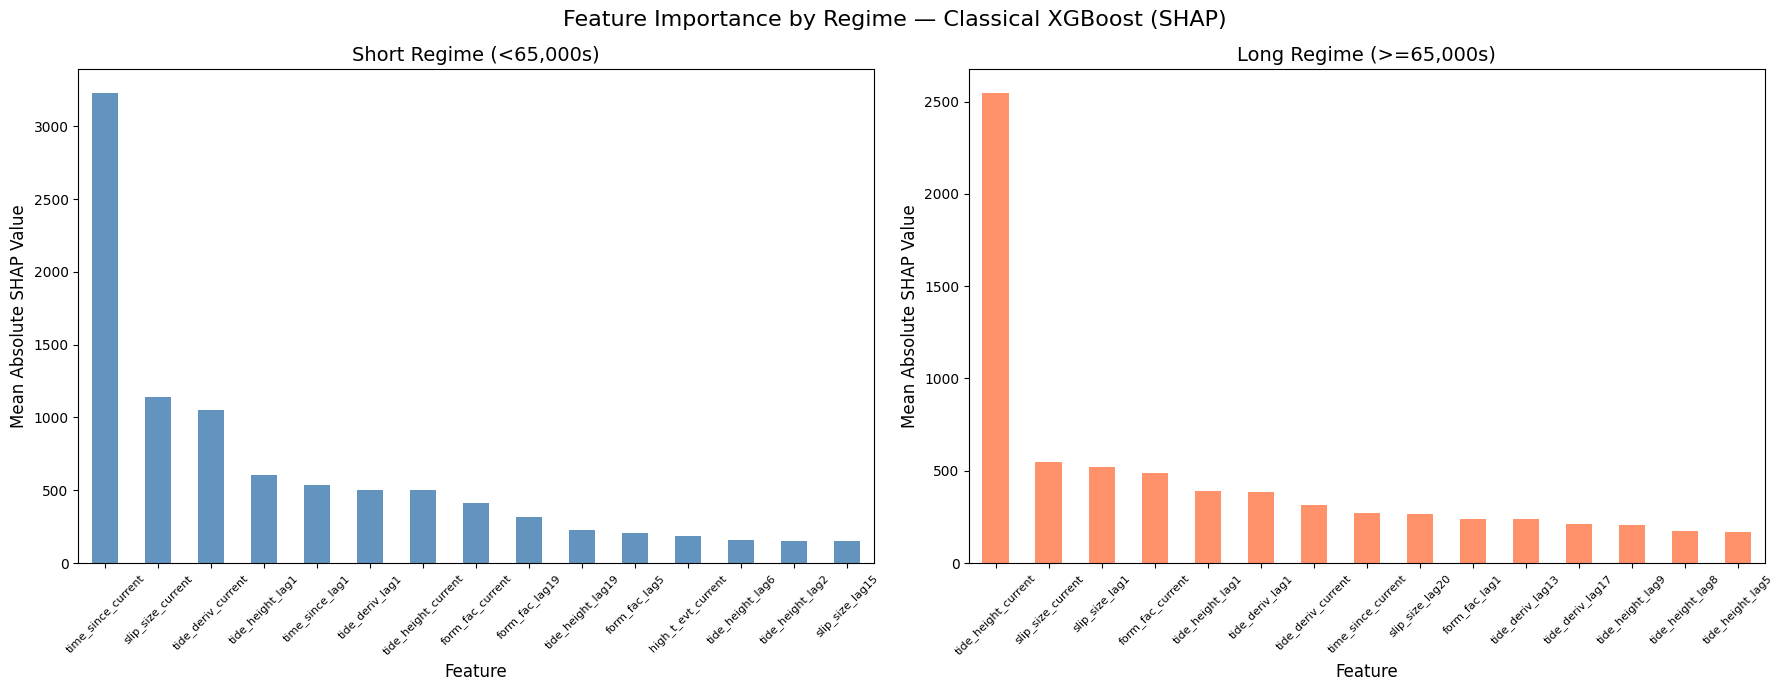


=== SHAP importance grouped by base feature ===
Short regime (grouped):
time_since     4856.524185
tide_deriv     2924.759976
slip_size      2604.399267
tide_height    2459.848777
form_fac       2158.383638
high_t_evt      347.195636
dtype: float64

Long regime (grouped):
tide_height    4433.490981
tide_deriv     2463.764355
slip_size      2430.066501
time_since     1992.959736
form_fac       1750.947060
high_t_evt       90.887623
dtype: float64


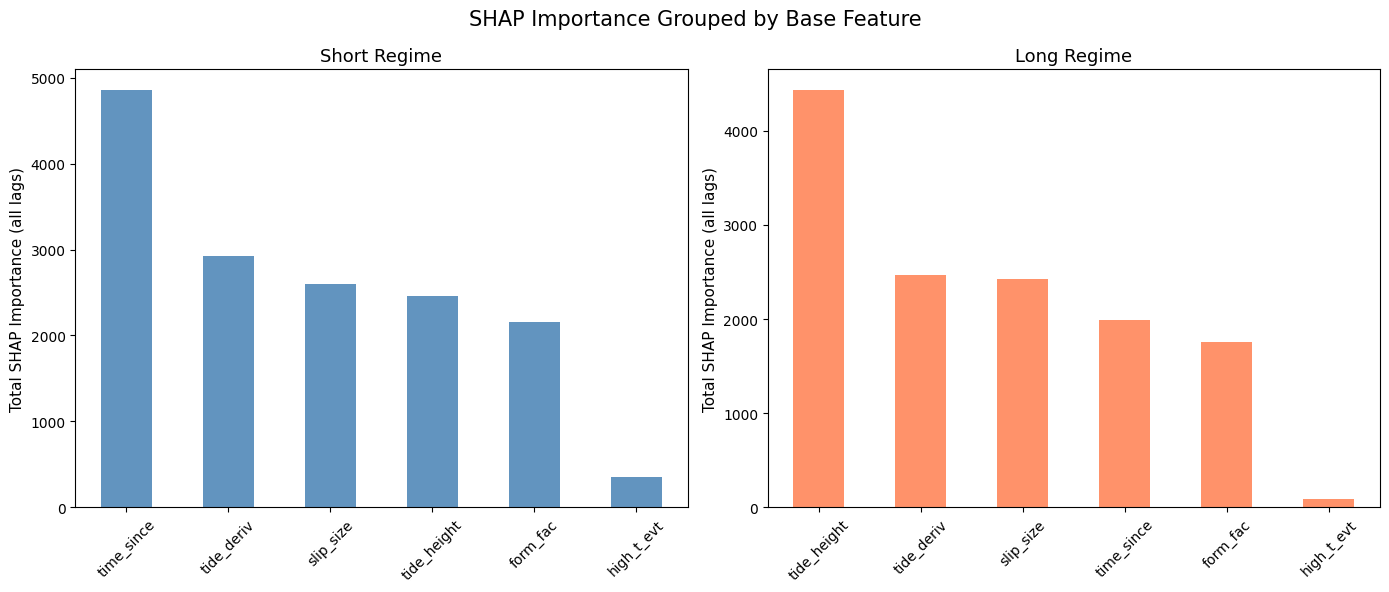

In [9]:
# ── Cell 2 FIXED: Generate full 126 feature names + SHAP per regime ───────────
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

n_previous_events = 20

# Generate full windowed feature names — 21 events x 6 base features
base_feature_names = list(feature_cols)  # the 6 base names
full_feature_names = []
for event_idx in range(n_previous_events + 1):
    if event_idx == 0:
        suffix = "_current"
    else:
        suffix = f"_lag{event_idx}"
    for fname in base_feature_names:
        full_feature_names.append(f"{fname}{suffix}")

print(f"X_test_np columns: {X_test_np.shape[1]}")
print(f"Generated feature names: {len(full_feature_names)}")
assert X_test_np.shape[1] == len(full_feature_names), \
    f"Still mismatched: {X_test_np.shape[1]} vs {len(full_feature_names)}"

# ── Short regime SHAP ─────────────────────────────────────────────────────────
X_shap_short = pd.DataFrame(
    X_test_np[short_true_idx],
    columns=full_feature_names
)
explainer_short = shap.TreeExplainer(
    XGBoost_short,
    pd.DataFrame(X_tr_short, columns=full_feature_names),
    feature_perturbation="interventional"
)
shap_values_short = explainer_short.shap_values(X_shap_short)
short_imp = pd.Series(
    np.abs(shap_values_short).mean(axis=0),
    index=full_feature_names
).sort_values(ascending=False)

print("\nTop 15 Short Regime Drivers:")
print(short_imp.head(15))

# ── Long regime SHAP ──────────────────────────────────────────────────────────
X_shap_long = pd.DataFrame(
    X_test_np[long_true_idx],
    columns=full_feature_names
)
explainer_long = shap.TreeExplainer(
    XGBoost_long,
    pd.DataFrame(X_tr_long, columns=full_feature_names),
    feature_perturbation="interventional"
)
shap_values_long = explainer_long.shap_values(X_shap_long)
long_imp = pd.Series(
    np.abs(shap_values_long).mean(axis=0),
    index=full_feature_names
).sort_values(ascending=False)

print("\nTop 15 Long Regime Drivers:")
print(long_imp.head(15))

# ── Side by side — top 15 features per regime ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Importance by Regime — Classical XGBoost (SHAP)", fontsize=16)

short_imp.head(15).sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color='steelblue', alpha=0.85
)
axes[0].set_title("Short Regime (<65,000s)", fontsize=14)
axes[0].set_ylabel("Mean Absolute SHAP Value", fontsize=12)
axes[0].set_xlabel("Feature", fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)

long_imp.head(15).sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color='coral', alpha=0.85
)
axes[1].set_title("Long Regime (>=65,000s)", fontsize=14)
axes[1].set_ylabel("Mean Absolute SHAP Value", fontsize=12)
axes[1].set_xlabel("Feature", fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

# ── Grouped by base feature — sum SHAP importance across all lag versions ─────
# This shows which of the 6 base features matter most regardless of lag
print("\n=== SHAP importance grouped by base feature ===")
short_grouped = {}
long_grouped  = {}

for fname in base_feature_names:
    cols = [c for c in full_feature_names if c.startswith(fname)]
    short_grouped[fname] = short_imp[cols].sum()
    long_grouped[fname]  = long_imp[cols].sum()

short_grouped = pd.Series(short_grouped).sort_values(ascending=False)
long_grouped  = pd.Series(long_grouped).sort_values(ascending=False)

print("Short regime (grouped):")
print(short_grouped)
print("\nLong regime (grouped):")
print(long_grouped)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SHAP Importance Grouped by Base Feature", fontsize=15)

short_grouped.plot(kind="bar", ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title("Short Regime", fontsize=13)
axes[0].set_ylabel("Total SHAP Importance (all lags)", fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)

long_grouped.plot(kind="bar", ax=axes[1], color='coral', alpha=0.85)
axes[1].set_title("Long Regime", fontsize=13)
axes[1].set_ylabel("Total SHAP Importance (all lags)", fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

Total misrouted: 91 / 565
Total correctly routed: 474 / 565

Closest temporally proximate pair:
  Correctly routed index: 5
  Misrouted index:        6
  Index gap:              1

Feature                                     Correct       Misrouted         Diff
--------------------------------------------------------------------------------
tide_deriv                                   0.0363         -0.1494      -0.1857
form_fac                                     3.9307          1.7699      -2.1608
time_since                               54795.0000      87300.0000   32505.0000
slip_size                                   -0.4455          1.2855       1.7309
high_t_evt                                   1.0000          1.0000       0.0000
tide_height                                 60.8816         29.9030     -30.9786

True inter-event time:
  Correctly routed: 95370s (26.5 hrs) — true regime: Long — predicted: Long
  Misrouted:        61440s (17.1 hrs) — true regime: Short — predicted:

C:\Users\kaitl\AppData\Local\Temp\ipykernel_56496\1961179187.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(base_feature_names, rotation=45, ha='right', fontsize=9)


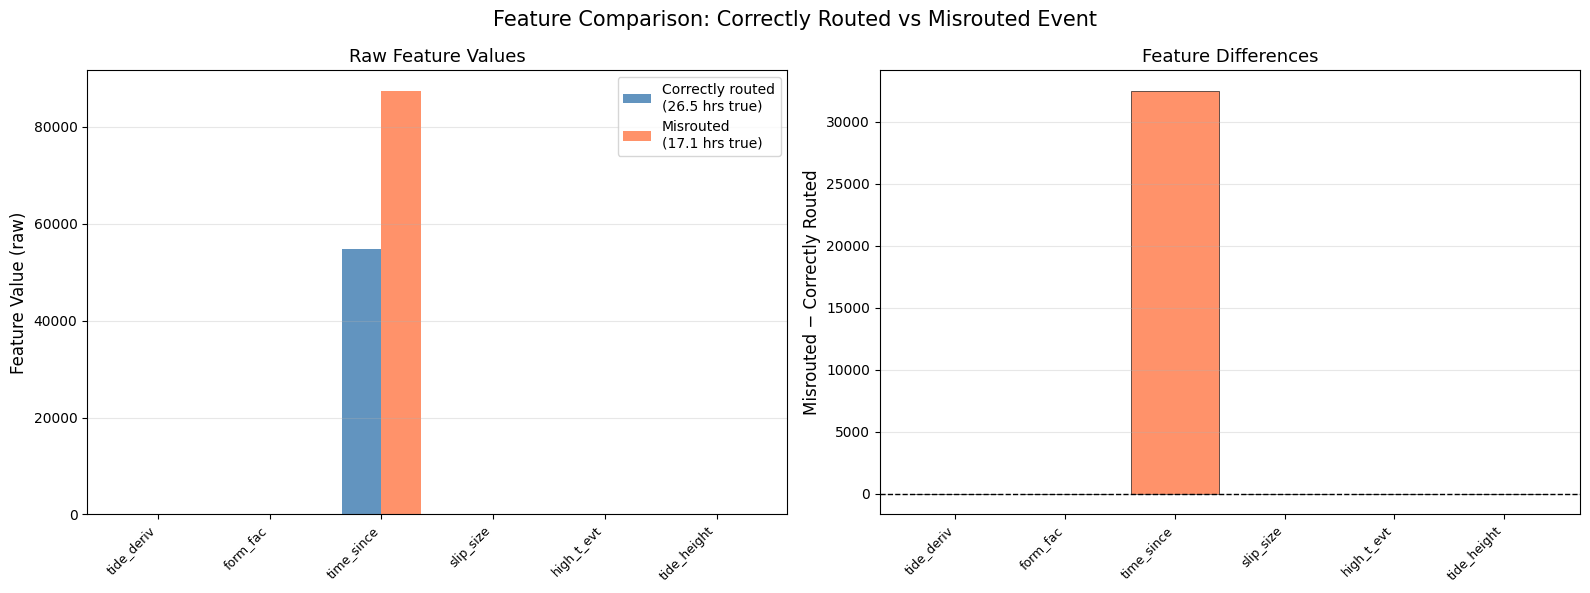

In [10]:
# ── Cell 3: Correctly routed vs misrouted event feature comparison ─────────────
clf_test_labels  = slip_classifier.predict(X_test_np)
true_test_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)

misrouted_idx = np.where(clf_test_labels != true_test_labels)[0]
correct_idx   = np.where(clf_test_labels == true_test_labels)[0]

print(f"Total misrouted: {len(misrouted_idx)} / {len(y_test_np)}")
print(f"Total correctly routed: {len(correct_idx)} / {len(y_test_np)}")

if len(misrouted_idx) == 0:
    print("No misrouted samples found — classifier was perfect on test set.")
else:
    # Find closest pair by dataset index (proxy for temporal proximity)
    best_pair = None
    best_gap  = np.inf
    for m_idx in misrouted_idx:
        for c_idx in correct_idx:
            gap = abs(int(m_idx) - int(c_idx))
            if gap < best_gap:
                best_gap  = gap
                best_pair = (c_idx, m_idx)

    correct_sample_idx, misrouted_sample_idx = best_pair

    print(f"\nClosest temporally proximate pair:")
    print(f"  Correctly routed index: {correct_sample_idx}")
    print(f"  Misrouted index:        {misrouted_sample_idx}")
    print(f"  Index gap:              {best_gap}")

    # Use only the 6 base features of the current event
    # These are the first 6 columns of the windowed feature matrix
    n_feat_per_event   = X_test_np.shape[1] // (n_previous_events + 1)
    base_feature_names = feature_cols[:n_feat_per_event]
    correct_features   = X_test_np[correct_sample_idx,  :n_feat_per_event]
    misrouted_features = X_test_np[misrouted_sample_idx, :n_feat_per_event]

    print(f"\n{'Feature':<35} {'Correct':>15} {'Misrouted':>15} {'Diff':>12}")
    print("-" * 80)
    for i, fname in enumerate(base_feature_names):
        diff = misrouted_features[i] - correct_features[i]
        print(f"{fname:<35} {correct_features[i]:>15.4f} "
              f"{misrouted_features[i]:>15.4f} {diff:>12.4f}")

    print(f"\nTrue inter-event time:")
    print(f"  Correctly routed: {y_test_np[correct_sample_idx]:.0f}s "
          f"({y_test_np[correct_sample_idx]/3600:.1f} hrs) — "
          f"true regime: {'Short' if true_test_labels[correct_sample_idx]==0 else 'Long'} — "
          f"predicted: {'Short' if clf_test_labels[correct_sample_idx]==0 else 'Long'}")
    print(f"  Misrouted:        {y_test_np[misrouted_sample_idx]:.0f}s "
          f"({y_test_np[misrouted_sample_idx]/3600:.1f} hrs) — "
          f"true regime: {'Short' if true_test_labels[misrouted_sample_idx]==0 else 'Long'} — "
          f"predicted: {'Short' if clf_test_labels[misrouted_sample_idx]==0 else 'Long'}")

    print(f"\nPrediction errors:")
    print(f"  Correctly routed — Predicted: {final_predictions[correct_sample_idx]:.0f}s  "
          f"Error: {abs(final_predictions[correct_sample_idx] - y_test_np[correct_sample_idx]):.0f}s")
    print(f"  Misrouted        — Predicted: {final_predictions[misrouted_sample_idx]:.0f}s  "
          f"Error: {abs(final_predictions[misrouted_sample_idx] - y_test_np[misrouted_sample_idx]):.0f}s")

    # ── Visual ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "Feature Comparison: Correctly Routed vs Misrouted Event",
        fontsize=15
    )

    x     = np.arange(len(base_feature_names))
    width = 0.35

    # Panel 1: side by side bar chart of raw feature values
    axes[0].bar(
        x - width/2, correct_features, width,
        label=f"Correctly routed\n({y_test_np[correct_sample_idx]/3600:.1f} hrs true)",
        color='steelblue', alpha=0.85
    )
    axes[0].bar(
        x + width/2, misrouted_features, width,
        label=f"Misrouted\n({y_test_np[misrouted_sample_idx]/3600:.1f} hrs true)",
        color='coral', alpha=0.85
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(base_feature_names, rotation=45, ha='right', fontsize=9)
    axes[0].set_ylabel("Feature Value (raw)", fontsize=12)
    axes[0].set_title("Raw Feature Values", fontsize=13)
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)

    # Panel 2: difference plot
    diffs  = misrouted_features - correct_features
    colors = ['coral' if d > 0 else 'steelblue' for d in diffs]
    axes[1].bar(
        base_feature_names, diffs,
        color=colors, alpha=0.85, edgecolor='black', linewidth=0.5
    )
    axes[1].axhline(0, color='black', linewidth=1.0, linestyle='--')
    axes[1].set_xticklabels(base_feature_names, rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel("Misrouted − Correctly Routed", fontsize=12)
    axes[1].set_title("Feature Differences", fontsize=13)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [13]:
# Good XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("MAE XGBoost Error:", XGBoost_Error_MAE)

[I 2026-04-13 12:36:53,956] A new study created in memory with name: no-name-703bf92c-447f-4946-9dfd-4609638b681d
[I 2026-04-13 12:36:58,952] Trial 0 finished with value: 16610.68673179424 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 16610.68673179424.
[I 2026-04-13 12:37:00,810] Trial 1 finished with value: 17696.51490712202 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 16610.68673179424.
[I 2026-04-13 12:37:04,533] Trial 2 finished with value: 16910.393565186347 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 16610.68673179424.
[I 2026-04-13 12:37:06,413] Trial 3 finished with value: 17501.307795621797 and pa

Optimal Parameters: {'learning_rate': 0.031580904152223435, 'max_depth': 5, 'subsample': 0.8407951398015077, 'colsample_bytree': 0.8685684874126708}
XGBoost Error: 15156.766613104091
MAE XGBoost Error: 11353.133382881637


In [12]:
'''# XGBoost with sample weighting for long inter-event times

# Sample weights — upweight top 25% longest intervals 3x
sample_weights_train = np.where(
    y_train > np.percentile(y_train, 75),
    3.0,
    1.0
)

# Tuning XGBoost through the Optuna library
def objective(trial):
    XGBoost = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42
    )
    XGBoost.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,  # added
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    predictions = XGBoost.predict(X_val)
    RMSE = root_mean_squared_error(y_val, predictions)
    return RMSE

# Finding the parameters that minimize the squared error
optimization = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
optimization.optimize(objective, n_trials=30)

optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

# Running XGBoost with optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,  # added
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluation
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost RMSE:", XGBoost_Error)

XGBoost_MAE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_MAE
print("MAE XGBoost Error:", XGBoost_Error_MAE)'''

'# XGBoost with sample weighting for long inter-event times\n\n# Sample weights — upweight top 25% longest intervals 3x\nsample_weights_train = np.where(\n    y_train > np.percentile(y_train, 75),\n    3.0,\n    1.0\n)\n\n# Tuning XGBoost through the Optuna library\ndef objective(trial):\n    XGBoost = XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=1000,\n        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),\n        max_depth=trial.suggest_int("max_depth", 2, 5),\n        subsample=trial.suggest_float("subsample", 0.6, 0.9),\n        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),\n        random_state=42\n    )\n    XGBoost.fit(\n        X_train, y_train,\n        sample_weight=sample_weights_train,  # added\n        eval_set=[(X_val, y_val)],\n        verbose=False\n    )\n    predictions = XGBoost.predict(X_val)\n    RMSE = root_mean_squared_error(y_val, predictions)\n    return RMSE\n\n# Finding the paramet

[ 87450.  58215.  88560.  31005.  36825.  95370.  61440.  52110.  56520.
  35355.  87870.  31620.  39930.  28455.  33600.  53310.  37860.  31860.
  88095.  86880.  30930.  44865.  61215.  92535.  82170.  58800.  47265.
  46530.  47385.  87165.  82605.  38490.  68520.  74535.  34755.  32295.
  82740.  56490.  90435.  40005.  44715.  43500.  72435.  27930.  57885.
  88830.  81120.  89175.  52890.  57810.  89610.  54630. 100845.  52155.
  85905.  55185.  61605.  88710.  52635.  53520.  87705.  54540.  92775.
  34425.  39165.  75540.  77760.  48060.  38085.  43395.  42975.  63915.
  90675.  45660.  73605.  90135.  31740.  84930.  83520.  48780.  93975.
  44235.  86700.  53850.  79800.  36510.  91560.  56790.  85785.  75570.
  37545.  69570.  57225.  34500.  49845.  84885.  53865. 100995.  49710.
  44835.  87690.  84750.  50295.  55035.  30360.  41535.  79515.  47445.
  87960.  46770.  52575.  47355.  87330.  41745.  53775.  35775.  28035.
  45285.  85755.  51750.  29355.  37575.  31890.  4

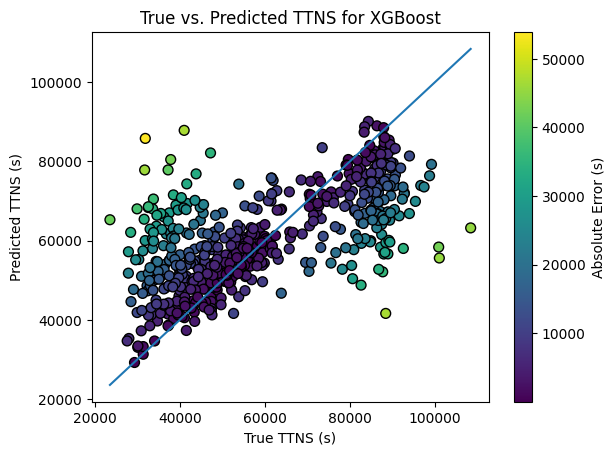

In [13]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

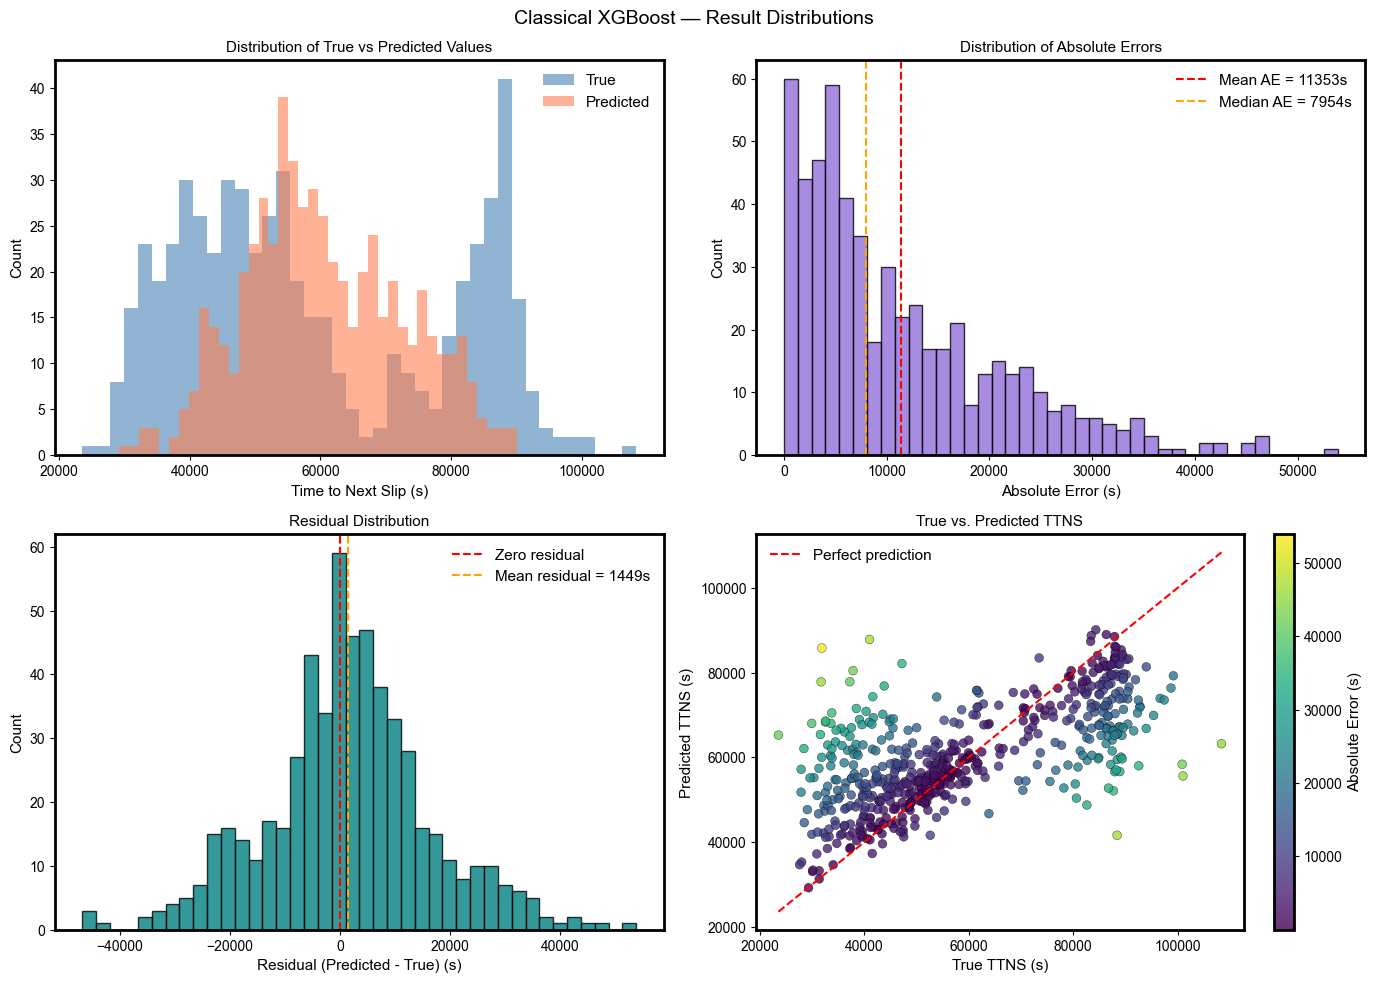

MAE:            11353.13s
Median AE:      7953.77s
RMSE:           15156.77s
R2:             0.4337
Max error:      53889.53s
% within 5000s: 34.9%
% within 9000s: 53.1%


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for Classical XGBoost ─────────────────────────────
y_test_secs   = y_test
XG_pred_secs  = XGBoost_Prediction

absolute_errors = np.abs(XG_pred_secs - y_test_secs)
residuals       = XG_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Classical XGBoost — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(XG_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ─────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, XG_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, XG_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, XG_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")

In [15]:
'''# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
plt.xticks(fontsize=14)   # <-- Increase x-axis label size
plt.yticks(fontsize=12)
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers", fontsize=20)
plt.ylabel("Mean Absolute SHAP Value", fontsize=18)
plt.xlabel("Feature", fontsize=18)
plt.show()'''


'# Driving parameters for XG \n\n#Using the shap library with a copy of the training data to find the driving parameters\nX_shap = X_test.copy()\nX_shap = pd.DataFrame(X_shap, columns=feature_cols)\nexplainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features\n\nshap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data\n\nXG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG\n\nprint("XG Boost Drivers:", XG_imp)\n\n# Creating a bar graph showing the driving parameters for XGBoost \nplt.figure(figsize=(10, 6))\nplt.xticks(fontsize=14)   # <-- Increase x-axis label size\nplt.yticks(fontsize=12)\nXG_imp.sort_values(ascending=False).plot(kind="bar")\nplt.title("XG Boost Drivers", fontsize=20)\nplt.ylabel("Mean Absolute SHAP Value", fontsize=18)\nplt.xlabel("Feature

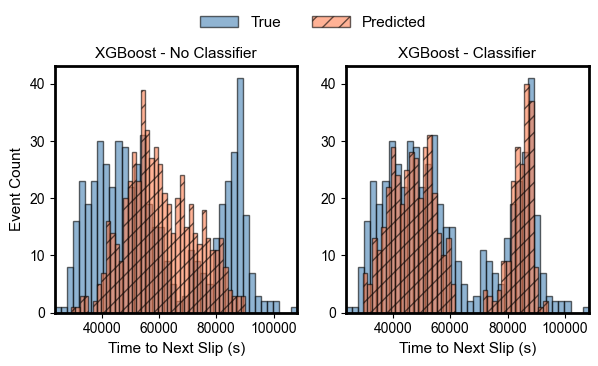

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

# Ensure numpy
y_classical = y_test if isinstance(y_test, np.ndarray) else y_test.to_numpy()
y_constrained = y_test_np

# IMPORTANT: use correct prediction variables
pred_classical = XG_pred_secs          # <-- from your FIRST code block
pred_constrained = final_predictions   # <-- from constrained pipeline

# ============================================================
# FIGURE 2 — TRUE DOUBLE PANEL (DIFFERENT DISTRIBUTIONS)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(6.89, 3.2))

# ── PANEL A: Classical (TOP-LEFT FROM FIRST FIGURE) ──────────
axes[0].hist(
    y_classical,
    bins=40,
    alpha=0.6,
    color='steelblue',
    label='True',
    edgecolor='black'
)

axes[0].hist(
    pred_classical,
    bins=40,
    alpha=0.6,
    color='coral',
    label='Predicted',
    edgecolor='black',
    hatch='//'   # <-- grayscale-safe encoding
)

axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Event Count")
axes[0].set_title("XGBoost - No Classifier")

style_axes(axes[0])

# ── PANEL B: Constrained (TOP-LEFT FROM SECOND FIGURE) ───────
axes[1].hist(
    y_constrained,
    bins=40,
    alpha=0.6,
    color='steelblue',
    label='True',
    edgecolor='black'
)

axes[1].hist(
    pred_constrained,
    bins=40,
    alpha=0.6,
    color='coral',
    label='Predicted',
    edgecolor='black',
    hatch='//'
)



axes[1].set_xlabel("Time to Next Slip (s)")
#axes[1].set_ylabel("Count")
axes[1].set_title("XGBoost - Classifier")

style_axes(axes[1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    handlelength=2.5,     # longer legend symbols
    handletextpad=0.8,    # space between symbol and text
    columnspacing=2.0     # space between columns
)



# ── Match axis limits (CRITICAL for comparison) ─────────────
xmin = min(y_classical.min(), y_constrained.min(),
           pred_classical.min(), pred_constrained.min())
xmax = max(y_classical.max(), y_constrained.max(),
           pred_classical.max(), pred_constrained.max())

for ax in axes:
    ax.set_xlim(xmin, xmax)
plt.show()
# ── Layout + save ──────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.9])

#This does not actually do it 
plt.savefig("figure_bimodal_doublepanel.pdf", dpi=600, bbox_inches='tight')
plt.close()